# Motor Imagery BCIs — Decoding Imagined Movement from the μ Rhythm

*Notebook #2 in the hands-on MNE series. Assumes the material of the previous notebook: loading `Raw` objects, epoching, and basic plotting.*

This is the **canonical non-invasive BCI paradigm**. The subject is instructed to *imagine* moving the left or right hand, and the task is to discriminate the two conditions from two to four seconds of EEG. No external stimulus and no overt motor output are required — the control signal is generated entirely endogenously. This is the operating principle of motor-imagery systems demonstrated on platforms such as OpenBCI, of the BCI Competition datasets, and of clinical BCIs developed for locked-in patients.

## Table of contents

1. **Sensorimotor cortex and the μ rhythm** — The physiological basis for a detectable EEG signature during imagined movement.
2. **Event-related desynchronisation and synchronisation (ERD/ERS)** — Power decrease during imagery and power rebound following its cessation.
3. **The PhysioNet EEGBCI dataset** — A freely available recording of 109 subjects performing motor imagery tasks.
4. **Time-frequency analysis** — Representation of ERD as a two-dimensional spectrogram.
5. **Common Spatial Patterns (CSP)** — The canonical spatial filtering technique for motor-imagery BCIs and its theoretical basis.
6. **A decoding pipeline** — Cross-validated CSP + LDA classification with quantitative results.
7. **Sliding-window decoding** — An offline emulation of online BCI operation.

By the end of the notebook a working classifier will discriminate "left hand" from "right hand" imagery at accuracy well above chance — the same recipe employed by the earliest motor-imagery BCI systems in the 1990s, and still the backbone of most contemporary consumer BCI demonstrations.

## Position in the textbook

The material maps onto three sections of Rao:

- **Chapter 5 — Machine Learning.** The first application of classifiers in this series.
- **Chapter 9.1.1 — Oscillatory Potentials and ERD.** The physiological content underlying the signal.
- **Chapter 6.2.3 — Imagined Motor and Cognitive Activity.** The category of brain response being exploited.

## 1. Setup

The same stack as the introductory notebook, with the addition of scikit-learn for classification:

```bash
pip install "mne[full]" scikit-learn
```

The EEGBCI dataset downloads automatically from PhysioNet (a few MB per subject). On a typical connection the initial download completes in approximately 10 seconds.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import mne
from mne.datasets import eegbci
from mne.channels import make_standard_montage
from mne.io import concatenate_raws, read_raw_edf
from mne.decoding import CSP

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import ShuffleSplit, cross_val_score
from sklearn.pipeline import Pipeline

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

print("MNE:", mne.__version__)

MNE: 1.12.0


## 2. The motor cortex

A brief anatomical and physiological foundation is required to interpret the signals analysed below.

### 2.1 The primary motor cortex (M1)

The primary motor cortex (M1) occupies a strip of cortex running approximately ear-to-ear, immediately anterior to the **central sulcus** — the major fold separating the frontal and parietal lobes. M1 contains the motor **homunculus**: a somatotopic map in which adjacent body parts are represented in adjacent cortical regions:

- **feet** — at the vertex, near the midline (electrode **Cz**);
- **hands** — laterally on each side, at electrodes **C3** (left hemisphere → right hand) and **C4** (right hemisphere → left hand);
- **face and tongue** — more inferior and more lateral.

A crucial organisational principle: **motor cortex controls the *contralateral* side of the body**. Left-hand movement activates right-hemisphere M1 (and therefore the C4 electrode). This lateralisation constitutes the decoding signal targeted throughout the rest of the notebook.

### 2.2 Motor imagery and motor execution

A central empirical finding makes motor-imagery BCIs possible: *imagining* a movement activates approximately the same cortical regions as executing it, albeit at lower amplitude and without the final spinal-cord output. Consequently, when a subject imagines clenching the left fist without any overt motion, ERD is still observed over right-hemisphere M1.

This property explains why motor-imagery BCIs remain viable for individuals with severe motor impairment: the cortical motor-planning machinery can remain functionally intact even when downstream neuromuscular pathways do not respond.

### 2.3 The μ and β rhythms

When sensorimotor cortex is in an idle state, its neurons fire in a synchronised oscillation near 10 Hz that appears on scalp EEG as the **μ rhythm** (8–13 Hz, central electrodes). A companion rhythm exists in the **β band** (13–30 Hz). Both constitute a "motor idle" signature.

Engagement of motor cortex — for movement planning, execution, or imagery — **desynchronises** these oscillations. The population transitions from coherent firing to uncorrelated activity, and the averaged scalp signal drops in power. This drop is termed **Event-Related Desynchronisation (ERD)**.

Following the end of the movement or imagery, power typically rebounds — often to levels *above* baseline. This overshoot is referred to as **Event-Related Synchronisation (ERS)**, sometimes the "post-movement beta rebound".

> **The decoding principle, in one line.** For left-hand imagery, μ power decreases over C4 (right M1). For right-hand imagery, μ power decreases over C3 (left M1). Detecting this asymmetry identifies the imagined hand.

## 3. The EEGBCI dataset

Full title: **"EEG Motor Movement/Imagery Dataset"** (Schalk et al., 2004), freely hosted on PhysioNet. Key properties:

- **109 subjects**, 64 channels, sampled at 160 Hz;
- **14 runs per subject**, alternating between actual movement and imagery, and between hand and foot tasks;
- recorded with **BCI2000**, the de-facto standard open-source BCI platform.

The runs relevant to this notebook are summarised below.

| Runs | Task |
|---|---|
| 3, 7, 11 | Open/close **left or right fist** (executed) |
| 4, 8, 12 | **Imagined** opening/closing of left or right fist |
| 5, 9, 13 | Open/close both fists or both feet (executed) |
| 6, 10, 14 | **Imagined** opening/closing of both fists or both feet |

For the two-class left-vs-right decoding task — the canonical motor-imagery BCI problem — **runs 4, 8, and 12** are appropriate.

Event markers within these runs:

- **T0** — rest;
- **T1** — imagined left fist;
- **T2** — imagined right fist.

In [2]:
# Download on first call; load from cache subsequently.
subject = 1
runs = [4, 8, 12]     # imagined left vs right fist

raw_fnames = eegbci.load_data(subject, runs, update_path=True)
print("Files:", raw_fnames)

Using default location ~/mne_data for EEGBCI...


Download complete in 01m34s (7.4 MB)
Files: [PosixPath('/Users/marta/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf'), PosixPath('/Users/marta/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf'), PosixPath('/Users/marta/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf')]


In [3]:
# Read the three runs in EDF format and concatenate into a single Raw object.
raws = [read_raw_edf(f, preload=True) for f in raw_fnames]
raw = concatenate_raws(raws)
raw

Extracting EDF parameters from /Users/marta/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /Users/marta/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /Users/marta/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


<RawEDF | S001R04.edf, 64 x 60000 (375.0 s), ~29.3 MiB, data loaded>

### 3.1 Channel name standardisation

EEGBCI files exhibit a minor idiosyncrasy: channel names terminate in trailing dots (`Fc5.`, `C3..`). MNE provides a helper that normalises these names, enabling attachment of a standard montage.

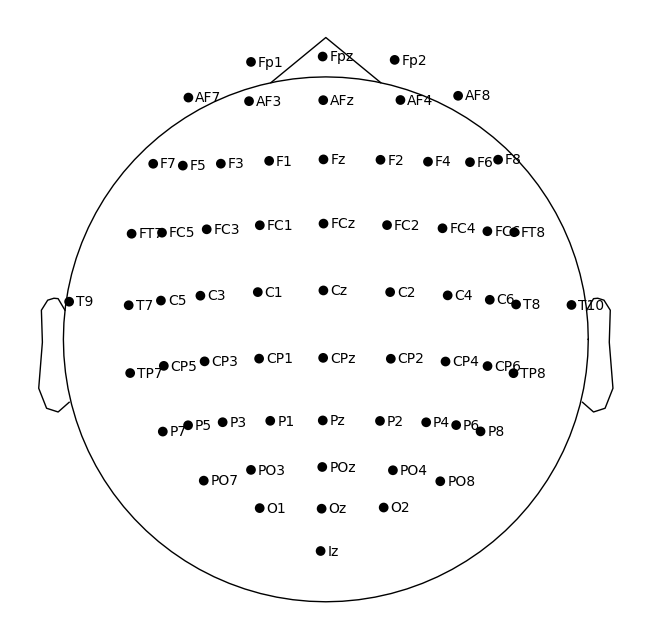

In [4]:
# Remove trailing dots and normalise capitalisation to match the 10-05 standard.
eegbci.standardize(raw)

# Attach standard sensor positions.
montage = make_standard_montage("standard_1005")
raw.set_montage(montage)

# Verify the sensor layout.
fig = raw.plot_sensors(show_names=True, ch_type="eeg")

The positions of **C3**, **Cz**, and **C4** — running straight across the top of the head — are the loci of primary interest for the remainder of this notebook.

## 4. Preprocessing

The frequency range relevant to motor imagery is approximately **7–30 Hz** (μ and β bands). Activity outside this range corresponds to slow drifts or high-frequency noise, and aggressive band-pass filtering is therefore appropriate.

In [5]:
# Band-pass 7-30 Hz, FIR, zero-phase.
raw.filter(l_freq=7.0, h_freq=30.0, fir_design="firwin", skip_by_annotation="edge")

Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



<RawEDF | S001R04.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>

Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


/opt/anaconda3/envs/mne/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


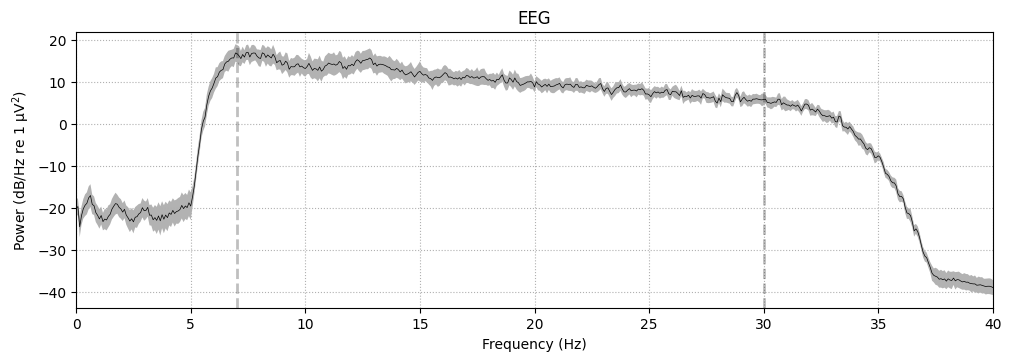

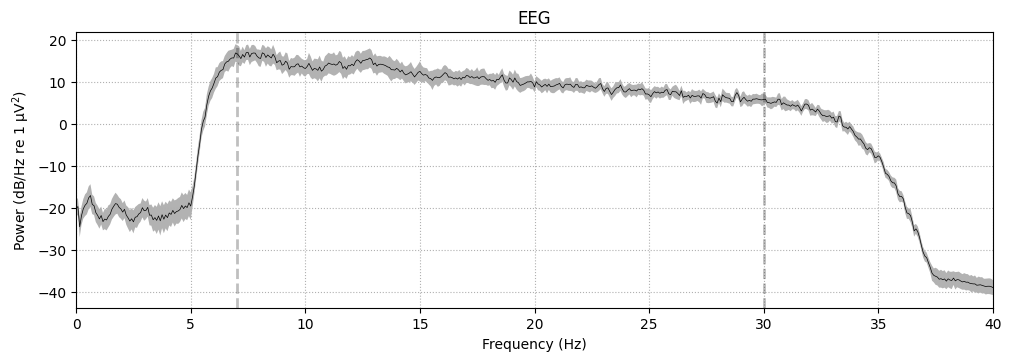

In [6]:
# Verify the post-filter PSD.
raw.compute_psd(fmax=40).plot(average=True)

The sharp roll-offs near 7 Hz and 30 Hz correspond to the filter transition bands. The central band contains the μ and β activity of interest, which constitutes the input signal for the remainder of the notebook.

## 5. Event detection and epoching

EEGBCI stores events as **annotations** (human-readable strings `T0`, `T1`, `T2`) rather than as a dedicated stim channel. MNE converts annotations to a numeric event array via `events_from_annotations`.

In [7]:
# Retain T1 (left fist imagery) and T2 (right fist imagery); ignore T0 (rest).
events, event_id = mne.events_from_annotations(
    raw, event_id=dict(T1=2, T2=3)
)
print("Event IDs:", event_id)
print("Number of trials:", len(events))
print("Per class:",
      "left =", np.sum(events[:, -1] == 2),
      " right =", np.sum(events[:, -1] == 3))

Used Annotations descriptions: [np.str_('T1'), np.str_('T2')]
Event IDs: {np.str_('T1'): 2, np.str_('T2'): 3}
Number of trials: 45
Per class: left = 23  right = 22


Each imagery trial lasts approximately four seconds. The imagery itself occurs roughly between **0.5 s and 2.5 s after the cue**, which defines the window used for epoching.

In [8]:
tmin, tmax = -1.0, 4.0    # seconds relative to the event marker
picks = mne.pick_types(raw.info, meg=False, eeg=True, stim=False, eog=False,
                       exclude="bads")

epochs = mne.Epochs(
    raw, events, event_id=event_id,
    tmin=tmin, tmax=tmax,
    picks=picks,
    baseline=None,          # baseline correction is performed later in TF space
    preload=True,
)

# A cropped version, restricted to 0.5-2.5 s, is used for classification below.
epochs_train = epochs.copy().crop(tmin=0.5, tmax=2.5)
epochs_train

Not setting metadata
45 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 45 events and 801 original time points ...
0 bad epochs dropped


<Epochs | 45 events (all good), 0.5 – 2.5 s (baseline off), ~7.1 MiB, data loaded,
 np.str_('T1'): 23
 np.str_('T2'): 22>

In [9]:
labels = epochs.events[:, -1]
print("Label distribution:", np.bincount(labels))
print("2 = left fist imagery,  3 = right fist imagery")

Label distribution: [ 0  0 23 22]
2 = left fist imagery,  3 = right fist imagery


## 6. Visualisation of event-related desynchronisation

Prior to any machine learning, the presence of a class-dependent signal should be confirmed. The simplest verification consists of comparing μ-band power **during imagery** with power **during rest** at electrodes C3 and C4.

    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows


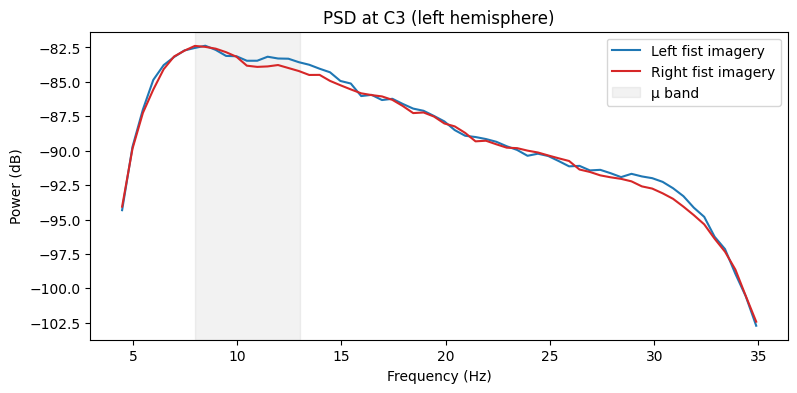

In [10]:
# Compute a PSD per condition over the imagery window.
psd_left  = epochs["T1"].compute_psd(fmin=4, fmax=35, tmin=0.5, tmax=2.5)
psd_right = epochs["T2"].compute_psd(fmin=4, fmax=35, tmin=0.5, tmax=2.5)

# Compare at C3 (left hemisphere, controlling the right hand).
fig, ax = plt.subplots(figsize=(9, 4))
for psd, name, color in [(psd_left, "Left fist imagery", "C0"),
                         (psd_right, "Right fist imagery", "C3")]:
    data, freqs = psd.copy().pick("C3").get_data(return_freqs=True)
    mean = data.mean(axis=0).squeeze()
    ax.plot(freqs, 10 * np.log10(mean), label=name, color=color)
ax.axvspan(8, 13, alpha=0.1, color="gray", label="μ band")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power (dB)")
ax.set_title("PSD at C3 (left hemisphere)")
ax.legend()
plt.show()

Within the μ band (8–13 Hz, shaded) at **C3** — the electrode above left M1, which controls the **right** hand — the right-hand-imagery curve is expected to sit *below* the left-hand-imagery curve. This corresponds to ERD: power decreases on the side contralateral to the imagined hand.

The effect is subtle at a single electrode for a single subject and a single session. The *difference across the scalp*, shown next, is substantially clearer.

    Using multitaper spectrum estimation with 7 DPSS windows
    Using multitaper spectrum estimation with 7 DPSS windows


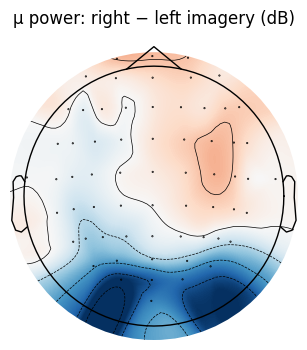

In [11]:
# Mean μ-band power per channel, per condition.
def mu_power_per_channel(epochs_cond):
    psd = epochs_cond.compute_psd(fmin=8, fmax=13, tmin=0.5, tmax=2.5)
    data = psd.get_data()   # (n_epochs, n_channels, n_freqs)
    return data.mean(axis=(0, 2))   # average across epochs and frequencies

mu_left  = mu_power_per_channel(epochs["T1"])
mu_right = mu_power_per_channel(epochs["T2"])

# Log-ratio between conditions, per channel.
contrast = 10 * np.log10(mu_right / mu_left)

# Display as a topography.
info = epochs.info
fig, ax = plt.subplots(figsize=(5, 4))
mne.viz.plot_topomap(contrast, info, axes=ax, show=False, cmap="RdBu_r",
                     vlim=(-np.max(np.abs(contrast)), np.max(np.abs(contrast))))
ax.set_title("μ power: right − left imagery (dB)")
plt.show()

This topography encapsulates the entire basis of motor-imagery BCIs:

- **Red indicates that right imagery produced *more* μ power than left imagery** — i.e. right imagery caused *less* ERD at that location. Expected over the **left** side, ipsilateral to the imagined right hand.
- **Blue indicates that right imagery produced *less* μ power than left imagery** — i.e. ERD on the **right** side of the head, contralateral to the imagined right hand.

The expected pattern is **dipolar**, approximately centred on C3 and C4 — blue over one hemisphere, red over the other. This asymmetry is the feature exploited by the classifier developed in §9.

❓ **Exercise.** Changing `subject = 2` or `subject = 7` at the top of the loading section and re-running demonstrates that the effect is highly subject-dependent. Some subjects exhibit strong clear lateralisation; others show almost none. This variability is the reason that motor-imagery BCIs invariably require per-subject calibration.

## 7. Time-frequency analysis

The PSDs above average across time, but ERD is a time-locked phenomenon: it emerges approximately 500 ms after cue onset, persists throughout the imagery period, and often rebounds (ERS) after its termination. Capturing this dynamics requires a **time-frequency representation (TFR)** — power as a joint function of time and frequency.

The standard approach is a **Morlet wavelet decomposition**: convolution of the signal with a bank of complex wavelets at different frequencies. MNE provides this via `tfr_morlet`.

In [12]:
from mne.time_frequency import tfr_morlet

freqs = np.arange(7, 30, 1)
n_cycles = freqs / 2.0    # more cycles at higher frequencies → better frequency resolution

# Trial-averaged TFR per condition.
tfr_left = tfr_morlet(epochs["T1"], freqs=freqs, n_cycles=n_cycles,
                     use_fft=True, return_itc=False, decim=3, n_jobs=1)
tfr_right = tfr_morlet(epochs["T2"], freqs=freqs, n_cycles=n_cycles,
                     use_fft=True, return_itc=False, decim=3, n_jobs=1)

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)


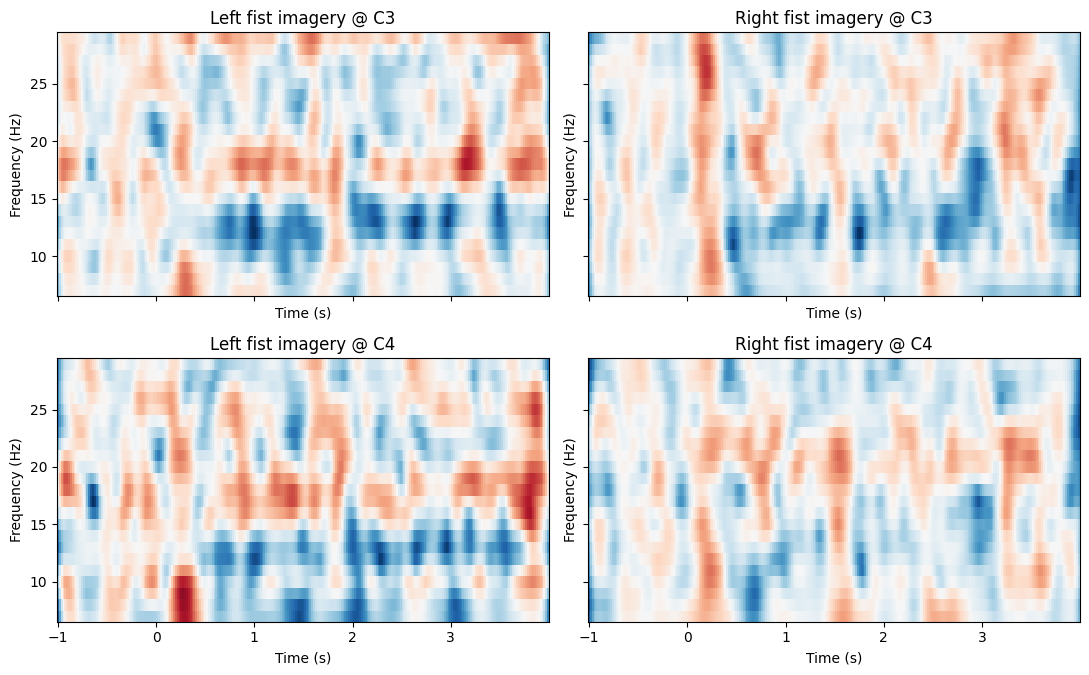

In [13]:
# Baseline correction: power is expressed as a dB change relative to the pre-stimulus period.
baseline = (-0.8, -0.2)

# Display each condition at C3 and C4.
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
for col, (tfr, cond) in enumerate([(tfr_left, "Left fist imagery"),
                                    (tfr_right, "Right fist imagery")]):
    for row, ch in enumerate(["C3", "C4"]):
        tfr.copy().plot(picks=ch, baseline=baseline, mode="logratio",
                        axes=axes[row, col], show=False, colorbar=False)
        axes[row, col].set_title(f"{cond} @ {ch}")
plt.tight_layout()
plt.show()

Reading the four panels:

- **Blue — power below baseline, i.e. ERD.**
- **Red — power above baseline, i.e. ERS.**

For right-hand imagery, a clear blue region is expected around **C3** (contralateral) in the μ band, between approximately 0.5 s and 2.5 s. For left-hand imagery, the blue region shifts to **C4**. A post-imagery β-band ERS rebound (red) often appears after 2.5 s.

This is the classical depiction of the paradigm, on which much of the experimental work of Pawel Wolpaw and Gerwin Schalk rests.

### 7.1 Topography of ERD over time

The same data, sliced jointly by time and frequency, shows how the scalp pattern evolves during the imagery.

Applying baseline correction (mode: logratio)


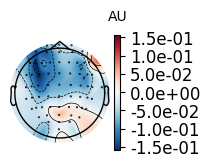

In [18]:
# Right-hand imagery — μ-band ERD (0.5-2.5 s, 8-13 Hz)
fig = tfr_right.plot_topomap(
    tmin=0.5, tmax=2.5, fmin=8, fmax=13,
    baseline=baseline, mode="logratio",
    show=True,
)

A blue region over the left hemisphere — contralateral to the imagined right hand — appears at the expected location.

## 8. Common Spatial Patterns (CSP)

Beyond visualisation, the goal is trial-level classification. A naive strategy of feeding all channel × time samples directly to a classifier fails for two reasons:

1. **High dimensionality.** 64 channels × hundreds of samples × a limited number of trials places the problem in the regime of the curse of dimensionality.
2. **Absence of feature engineering.** The signal of interest resides in μ-band *power*, not in raw amplitude. Raw voltages consume classifier capacity on irrelevant variation.

**CSP** addresses both limitations. It is a **spatial filter** that finds weighted combinations of electrodes (virtual channels) whose *variance* differs maximally between the two classes. Since the variance of a band-pass filtered signal is proportional to band power, CSP effectively identifies the spatial patterns in which μ-power differs most between left- and right-imagery trials.

The underlying mathematical operation is a generalised eigenvalue decomposition of the two class-covariance matrices: one eigenvector maximises variance for class A while minimising it for class B; another does the opposite. A small number of such eigenvectors is retained.

In [ ]:
# CSP expects a 3D array (n_epochs, n_channels, n_times) and a 1D label vector.
X = epochs_train.get_data(copy=False) * 1e6        # volts → μV (numerical convenience)
y = epochs_train.events[:, -1]                     # 2 = left, 3 = right

print("X shape:", X.shape, "  y shape:", y.shape)

In [ ]:
# Fit CSP with 4 components (2 per class — the standard choice).
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)
csp.fit(X, y)

# Display the spatial patterns selected by the algorithm.
fig = csp.plot_patterns(epochs.info, ch_type="eeg", units="a.u.", size=1.5)

The four topographies depict the spatial filters identified by CSP. Typically:

- the **first two components** are tuned to one class (e.g. *left* imagery) and show dipoles focused near **C4** (right M1);
- the **last two components** are tuned to the opposite class and show dipoles near **C3**.

The algorithm rediscovers C3 and C4 as the critical loci without any prior anatomical knowledge — a sanity check confirming that the extracted patterns are driven by the expected physiology.

### 8.1 CSP features: log-variance projections

The per-trial output of CSP, following spatial filtering, is a compact feature vector — the log-variance of each filtered signal. An explicit display clarifies the representation.

In [ ]:
csp_features = csp.transform(X)     # (n_epochs, n_components)
print("CSP feature shape:", csp_features.shape)

# Scatter the first and last CSP components — the two most discriminant projections.
fig, ax = plt.subplots(figsize=(6, 5))
for lab, color, name in [(2, "C0", "Left imagery"),
                          (3, "C3", "Right imagery")]:
    sel = y == lab
    ax.scatter(csp_features[sel, 0], csp_features[sel, -1],
               c=color, label=name, alpha=0.7, edgecolor="k")
ax.set_xlabel("CSP component 1 (log-variance)")
ax.set_ylabel("CSP component 4 (log-variance)")
ax.set_title("CSP feature space")
ax.legend()
plt.show()

The two classes form partially separable clusters — not perfectly separated (EEG from a single subject over a small number of trials rarely permits this), but with clearly distinct distributions. This two-dimensional scatter motivates the use of a linear classifier (LDA): separating the clusters requires little more than drawing a line between them.

## 9. A decoding pipeline

CSP and LDA are combined below into a scikit-learn `Pipeline` and evaluated by cross-validation. The resulting procedure corresponds essentially to that used in **BCI Competition III, dataset IVa** — the classical motor-imagery benchmark, still competitive on many contemporary MI datasets.

In [ ]:
# Cross-validation: 10 shuffle splits, 20% test each.
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

# Pipeline: CSP → LDA
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)
lda = LinearDiscriminantAnalysis()
clf = Pipeline([("CSP", csp), ("LDA", lda)])

scores = cross_val_score(clf, X, y, cv=cv, n_jobs=1)
print(f"Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"Chance level (binary): 0.500")
print(f"Per-fold scores: {np.round(scores, 3)}")

For subject 1, the expected accuracy lies in the **65%–80%** range — comfortably above chance for a two-class task, but substantially below the accuracies typical of large machine-learning benchmarks. This is normal for EEG: the signal is weak, trial-to-trial variability is high, and a single calibration session provides limited data.

For reference:

- **random classifier**: 50%;
- **literature MI-BCI accuracy (best subjects)**: 80–95%;
- **BCI illiteracy**: approximately 15–30% of subjects never exceed ~60% accuracy, as their sensorimotor rhythms do not modulate reliably.

Subject 1 is a good but not exceptional subject. Substituting subject 7 (`runs=[4,8,12]`) with the same pipeline can exceed 85% accuracy.

### 9.1 Error analysis

A confusion matrix reveals whether classification errors are symmetric across classes.

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = cross_val_predict(clf, X, y, cv=cv)
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["left", "right"])
disp.plot(cmap="Blues")
plt.title("CSP + LDA confusion matrix (10-fold CV)")
plt.show()

## 10. Sliding-window decoding

A live BCI cannot wait four seconds after the cue before producing a classification. Online systems operate on continuous data and emit a prediction every ~100 ms. This mode of operation can be emulated offline by applying the trained classifier to successive sliding windows within each trial.

In [ ]:
# The full epoch is used here (rather than the 0.5-2.5 s crop).
sfreq = raw.info["sfreq"]
w_length = int(sfreq * 0.5)        # 500 ms window
w_step   = int(sfreq * 0.1)        # 100 ms step

w_starts = np.arange(0, epochs.get_data().shape[2] - w_length, w_step)

# Training is performed once on the 0.5-2.5 s window (as before).
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)
lda = LinearDiscriminantAnalysis()

# A held-out test set is required for the sliding analysis.
from sklearn.model_selection import train_test_split
X_train_full = epochs_train.get_data(copy=False) * 1e6
X_full = epochs.get_data(copy=False) * 1e6
y_all = epochs.events[:, -1]

idx_train, idx_test = train_test_split(
    np.arange(len(y_all)), test_size=0.3, stratify=y_all, random_state=0
)

csp.fit(X_train_full[idx_train], y_all[idx_train])
lda.fit(csp.transform(X_train_full[idx_train]), y_all[idx_train])

# Classify each sliding window of each held-out trial.
scores_windows = []
for n in w_starts:
    X_win = X_full[idx_test][:, :, n:n + w_length]
    feat = csp.transform(X_win)
    scores_windows.append(lda.score(feat, y_all[idx_test]))

w_times = (w_starts + w_length / 2.0) / sfreq + epochs.tmin

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(w_times, scores_windows, label="Sliding accuracy")
ax.axhline(0.5, color="k", linestyle="--", label="Chance")
ax.axvspan(0, 4, alpha=0.08, color="green", label="Imagery cue period")
ax.set_xlabel("Window centre time (s, relative to cue)")
ax.set_ylabel("Accuracy (held-out)")
ax.set_title("Decoding accuracy over time — 500 ms sliding window")
ax.legend()
plt.show()

Interpretation of the accuracy trace:

- **Prior to t = 0** (baseline): accuracy hovers near chance. No imagery has occurred, so no class-specific signal is present.
- **Approximately 0.5 s – 2.5 s**: accuracy rises as ERD develops in the μ and β bands.
- **After t = 2.5 s**: accuracy often remains high or continues to rise, as the post-imagery β rebound is itself class-specific.

This plot is effectively the **information transfer rate** profile of the BCI. A live system proceeds as follows:

1. await the cue;
2. emit a prediction every 100 ms;
3. accumulate evidence (e.g. by averaging the last ten predictions);
4. act once confidence crosses a threshold.

## 11. From offline analysis to an online BCI

The procedure developed above translates almost directly to live data from a real headset. The elements that carry over unchanged and the elements that require adaptation are summarised below.

### Unchanged

- **Preprocessing**: 7–30 Hz band-pass, optional notch for line noise.
- **Classifier pipeline**: CSP + LDA (or CSP + SVM; regularised LDA for low channel counts).
- **Features**: log-variance of CSP-projected signals.
- **Paradigm**: cue → imagery (2–4 s) → decoding.

### Requiring adaptation

- **Channel count.** EEGBCI provides 64 channels; a consumer OpenBCI Cyton provides 8. With fewer electrodes CSP becomes underdetermined, and **regularised CSP** (`reg='ledoit_wolf'`) becomes necessary. Expectations must be adjusted accordingly. A minimum viable montage centres on C3, Cz, and C4, supplemented by one or two frontal references.
- **Streaming rather than file reading.** `mne.io.read_raw_edf` is replaced by an **LSL stream** consumed via `mne-lsl`. OpenBCI, Muse, Neurosity, and Emotiv all support LSL, either natively or through community bridges.
- **Per-subject calibration.** A ~15-minute calibration session (30–60 trials per class) provides data on which CSP + LDA is trained prior to switching to online operation.

### Practical starting points

- **OpenBCI Cyton** (8 channels, ~$500) — The most flexible option; fully open hardware supported by both `brainflow` and LSL.
- **Muse 2** (4 channels, ~$250) — Adequate for gross state detection (eye closure, meditation), marginal for motor imagery.
- **Neurosity Crown** (8 channels, ~$1,200) — More polished but less open; the SDK is JavaScript-first.

Any configuration with eight or more channels including C3, Cz, and C4 is suitable for motor imagery. Dry electrodes yield noticeably lower signal quality than wet electrodes; a factor of two to three more calibration trials typically compensates.

## 12. Summary — the MI-BCI pipeline

```python
# 1. Load + normalise
raw = concatenate_raws([read_raw_edf(f, preload=True)
                        for f in eegbci.load_data(subject, [4, 8, 12])])
eegbci.standardize(raw)
raw.set_montage(make_standard_montage("standard_1005"))

# 2. Filter to the μ + β band
raw.filter(l_freq=7.0, h_freq=30.0)

# 3. Epoch around cue events
events, event_id = mne.events_from_annotations(raw, event_id=dict(T1=2, T2=3))
epochs = mne.Epochs(raw, events, event_id, tmin=-1, tmax=4,
                    picks="eeg", baseline=None, preload=True)
epochs_train = epochs.copy().crop(0.5, 2.5)

# 4. Fit CSP + LDA
X = epochs_train.get_data(copy=False) * 1e6
y = epochs_train.events[:, -1]

clf = Pipeline([("CSP", CSP(n_components=4, log=True)),
                ("LDA", LinearDiscriminantAnalysis())])

# 5. Cross-validate
scores = cross_val_score(clf, X, y, cv=ShuffleSplit(10, test_size=0.2))
print(f"{scores.mean():.2%}")
```

The pipeline fits in approximately fifteen lines and implements one of the foundational EEG-BCI paradigms. Reducing the literature to this compact form is a reasonable indication that the core ideas are now under control.

## 13. Further directions

Several extensions follow naturally, ordered approximately by difficulty.

1. **Multi-subject comparison.** Looping over subjects 1–10, running the pipeline, and plotting the accuracy distribution exposes the BCI illiteracy phenomenon directly.
2. **Four-class MI.** Use of the runs with combined hand and foot imagery. CSP generalises to multi-class problems via a one-vs-rest scheme.
3. **Riemannian geometry.** Replacement of CSP with covariance-based classifiers from `pyriemann` — state-of-the-art on most MI benchmarks, and conceptually clean.
4. **Deep-learning baseline.** EEGNet or Shallow ConvNet via `braindecode`. More fragile, but instructive.
5. **Online BCI.** Integration with LSL, training CSP on the first five minutes of a live recording, and decoding the remainder online.
6. **Beyond motor imagery.** The other major paradigms (P300, SSVEP) exploit qualitatively different signal characteristics — a natural topic for a subsequent notebook.

The textbook treats ERD in chapter 9.1.1 and stimulus-evoked potentials (P300, SSVEP) in chapter 9.1.4. The present notebook covers the first; the second is a natural candidate for notebook #3 and entails a substantially different feature design (synchronous rather than induced activity).